# 06 Optimization Techniques

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Compare SGD and Adam optimizers on the same task (MNIST digits)
- See how the choice of optimizer affects loss curves and convergence
- Understand why we often use Adam instead of plain SGD

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 3, lesson 01 "Optimizers: SGD, Adam, and More" — the same comparison on a small mathematical problem; here it decides whether a network trains at all.

**Used later in:** Course 10 (AIAT 124) — Unit 1, lesson 08 "Training Techniques: Gradient Penalties and Spectral Normalization" — where optimizer choice keeps a GAN from collapsing.

---

## 🌍 Real life

**📌 Real case — the benchmark that refused to crown a winner.** Schmidt, Schneider and Hennig (ICML 2021, arXiv 2007.01547) took **15 popular deep-learning optimizers**, ran them across eight problems in more than **50,000 individual training runs**, and reported that they "cannot discern an optimization method clearly dominating across all tested tasks" — Adam remained a strong contender and newer methods failed to consistently beat it. Their other finding is the practical one: evaluating a handful of optimizers at their default settings works about as well as carefully tuning a single fixed optimizer. The controlled A/B you are about to run is one cell of that study.

**⚡ Why this matters — what goes wrong without it.** With plain SGD, one learning rate you picked by hand has to be right for every weight in the network at every stage of training. Too small and you get our SGD curve: after five full epochs the loss has crawled from **2.2705 to 1.9215** — the model has barely started. Too large and it diverges. Adam sidesteps the choice by giving every parameter its own effective step size. Same model, same data, **identical starting weights**: **0.3184**.

**Where is this used?** Every time you train a neural network you choose an **optimizer** that uses the gradients from backprop to update the weights (e.g. `optim.Adam(...)` in PyTorch or `optimizer='adam'` in Keras).

**In this notebook we use** **optimizers** (SGD and Adam) to **update the weights** so the network learns. We use **Adam** instead of plain **SGD** in many projects **because** Adam adapts the learning rate per parameter and usually **converges faster** and more reliably.

**📌 Covers slide(s):** Part of Unit 1 sequence (training flow). *Do after 05_backpropagation_detailed; then move to Unit 2.*

---

**Before starting:** Run the imports cell below. Requires PyTorch.


## Theory (short)

- **Optimizer** = algorithm that uses gradients to update weights: `new_weight = old_weight - learning_rate * gradient` (or a variant).
- **SGD (Stochastic Gradient Descent):** uses the gradient directly; simple but can be slow and sensitive to learning rate.
- **Adam:** adapts a learning rate per parameter (momentum + scaling); usually converges faster and is less sensitive to the initial learning rate.
- **Data flow:** forward pass → loss → backprop (gradients) → **optimizer** updates weights → repeat.

### Key math (required)

- **SGD:** \(w_{t+1} = w_t - \eta\, g_t\) where \(g_t = \nabla_w L\) (gradient of loss w.r.t. \(w\)) and \(\eta\) is the learning rate.
- **Adam:** maintains running estimates of the first moment \(m\) and second moment \(v\) of gradients; update: \(m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t\), \(v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2\), then bias-correct and apply \(w_{t+1} = w_t - \eta\,\hat{m}_t/(\sqrt{\hat{v}_t}+\epsilon)\). Typical \(\beta_1=0.9\), \(\beta_2=0.999\). See slides or Kingma & Ba (2014) for full form.

**The steps below put this theory into code.**

💡 **If this is unclear:** Focus on the **plot at the end**: one curve is SGD, one is Adam; Adam usually reaches lower loss in the same number of epochs. The main idea: optimizers use gradients to update weights; Adam adapts the step size per parameter. If stuck, tell your instructor: "I didn't get the SGD vs Adam part in notebook 06."


## 📥 Inputs & 📤 Outputs

**Inputs:** MNIST (we use a subset of 5k training samples), PyTorch, NumPy, Matplotlib. We build two identical small models in the notebook and train one with SGD and one with Adam.

**Dataset:** Real — MNIST (subset for SGD vs Adam comparison).

**Outputs:** Printed training loss per epoch for SGD, then for Adam; one plot with both curves (Adam typically reaches a lower loss in the same number of epochs); and **a storyboard of gradient descent walking down a real two-weight loss surface at three learning rates**, with the step table underneath.


In [1]:
# Step 1: Imports
# NumPy/Matplotlib for math and plots; torchvision supplies MNIST; DataLoader batches it.
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
print(f'PyTorch {torch.__version__}')
print('✅ Imports OK.')

PyTorch 2.13.0
✅ Imports OK.


In [2]:
# Step 2: Load MNIST (small subset so it runs fast)
transform = transforms.ToTensor()
train_data = datasets.MNIST('/tmp/mnist_data', train=True, download=True, transform=transform)
# Use first 5 000 samples for speed
subset = torch.utils.data.Subset(train_data, range(5000))
loader = DataLoader(subset, batch_size=128, shuffle=True)
print('Training on', len(subset), 'samples')

Training on 5000 samples


In [3]:
# Step 3: Factory function — same architecture used for both optimizers
def make_model():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 64), nn.ReLU(),
        nn.Linear(64, 10),
    )

# Fix the seed so the loss numbers quoted in the text are the ones this notebook prints.
torch.manual_seed(42)
model_sgd  = make_model()
model_adam = make_model()
# Copy weights so both models start identically
model_adam.load_state_dict(model_sgd.state_dict())
print('Both models initialised with identical weights')

Both models initialised with identical weights


In [4]:
# Step 4: Train with SGD
# SGD has a fixed learning rate; it takes longer to converge than Adam on many tasks.
criterion  = nn.CrossEntropyLoss()
opt_sgd    = optim.SGD(model_sgd.parameters(), lr=0.01)
losses_sgd = []
for epoch in range(5):
    model_sgd.train()
    epoch_loss = 0.0
    for xb, yb in loader:
        opt_sgd.zero_grad()
        loss = criterion(model_sgd(xb), yb)
        loss.backward()
        opt_sgd.step()
        epoch_loss += loss.item()
    losses_sgd.append(epoch_loss / len(loader))
    print(f'SGD  epoch {epoch+1}: loss={losses_sgd[-1]:.4f}')

SGD  epoch 1: loss=2.2705
SGD  epoch 2: loss=2.2018


SGD  epoch 3: loss=2.1179


SGD  epoch 4: loss=2.0234
SGD  epoch 5: loss=1.9215


In [5]:
# Step 5: Train with Adam (same architecture, same data, same starting weights)
# Adam adapts the learning rate per parameter — usually converges faster.
opt_adam    = optim.Adam(model_adam.parameters(), lr=1e-3)
losses_adam = []
for epoch in range(5):
    model_adam.train()
    epoch_loss = 0.0
    for xb, yb in loader:
        opt_adam.zero_grad()
        loss = criterion(model_adam(xb), yb)
        loss.backward()
        opt_adam.step()
        epoch_loss += loss.item()
    losses_adam.append(epoch_loss / len(loader))
    print(f'Adam epoch {epoch+1}: loss={losses_adam[-1]:.4f}')

Adam epoch 1: loss=1.6089


Adam epoch 2: loss=0.6850
Adam epoch 3: loss=0.4564


Adam epoch 4: loss=0.3761


Adam epoch 5: loss=0.3184


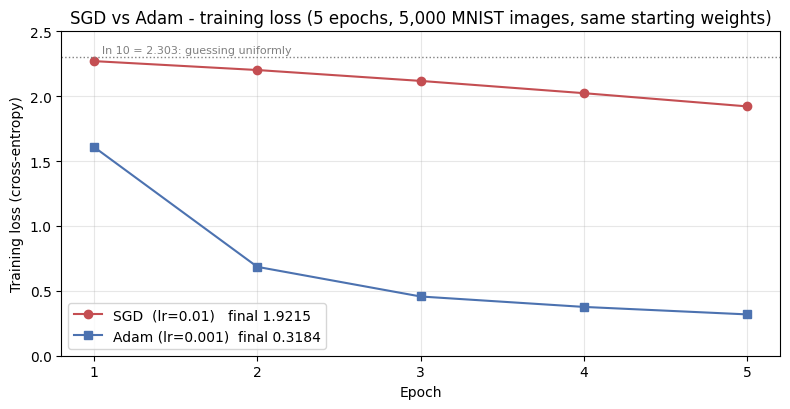

Adam final loss: 0.3184
SGD  final loss: 1.9215
After 5 epochs SGD has covered 17% of the way down from uniform guessing; Adam has covered 86%.


In [6]:
# Step 6: Plot loss comparison - SGD vs Adam
# WHY: both models started from IDENTICAL weights and saw identical batches, so the whole gap
#      between these two curves is the update rule and nothing else.
ep = np.arange(1, len(losses_sgd) + 1)          # epochs counted from 1, not from 0
plt.figure(figsize=(8, 4.2))
plt.plot(ep, losses_sgd,  "o-", color="#c44e52", label=f"SGD  (lr=0.01)   final {losses_sgd[-1]:.4f}")
plt.plot(ep, losses_adam, "s-", color="#4c72b0", label=f"Adam (lr=0.001)  final {losses_adam[-1]:.4f}")
# ln(10) is the loss of a model that answers "all ten digits equally likely" - the honest zero line.
plt.axhline(np.log(10), color="grey", ls=":", lw=1)
plt.text(1.05, np.log(10) + 0.03, "ln 10 = 2.303: guessing uniformly", fontsize=8, color="grey")
plt.title("SGD vs Adam - training loss (5 epochs, 5,000 MNIST images, same starting weights)")
plt.xlabel("Epoch"); plt.ylabel("Training loss (cross-entropy)")
plt.xticks(ep); plt.ylim(0, 2.5); plt.grid(alpha=0.3)
plt.legend(); plt.tight_layout(); plt.show()
print('Adam final loss:', round(losses_adam[-1], 4))
print('SGD  final loss:', round(losses_sgd[-1],  4))
print(f'After 5 epochs SGD has covered {(np.log(10)-losses_sgd[-1])/np.log(10)*100:.0f}% of the way '
      f'down from uniform guessing; Adam has covered {(np.log(10)-losses_adam[-1])/np.log(10)*100:.0f}%.')


**Read the figure.**

Both runs started from byte-identical weights (Step 3 copies them across) and saw the same 5,000 images, so every gap between the two lines is the update rule and nothing else. The dotted line at **ln 10 = 2.303** is where a model that answers "all ten digits equally likely" sits — the honest starting height for this loss, and a far more useful reference than zero.

After five epochs SGD has moved from 2.2705 to **1.9215**: about **17%** of the way down from uniform guessing. Adam is at **0.3184**, about **86%**. Look at the shape, not only the endpoint — SGD's line is still almost straight. It has not stalled or diverged; it is crawling, and it would keep going.

**What it does not prove:** that Adam is the better optimizer. Both step sizes were left at their library defaults (SGD 0.01, Adam 0.001) and neither was tuned. Step 7 shows exactly how much that single number decides.

## Step 7: The learning rate, seen on a real loss surface

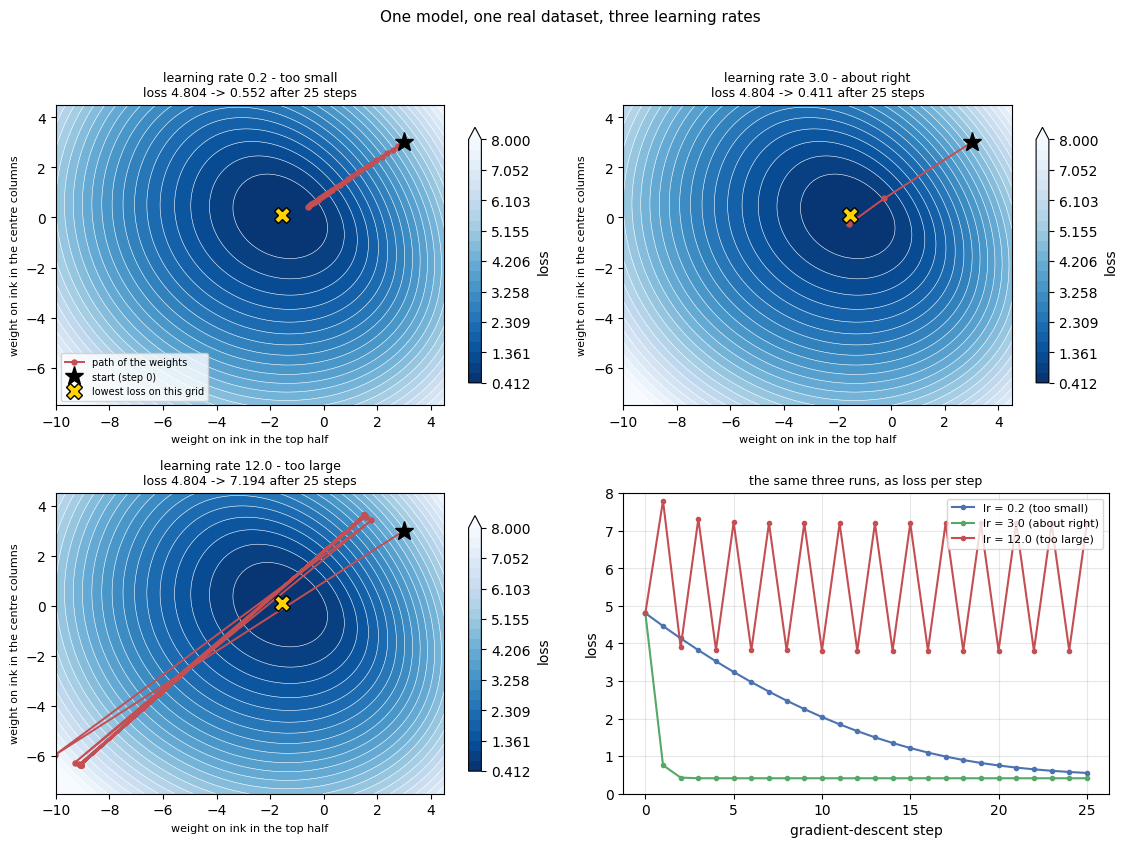

Images used: 823 real MNIST 0s and 1s. Lowest loss found on the grid: 0.4121 at w = (-1.56, 0.09)

lr = 0.2  (too small)
  step      w1      w2     loss
     0    3.00    3.00    4.804
     1    2.78    2.85    4.461
     2    2.57    2.70    4.133
     3    2.36    2.56    3.820
     4    2.16    2.42    3.522
     5    1.96    2.28    3.239
  ...  step 25: w = (-0.60, 0.43), loss 0.552

lr = 3.0  (about right)
  step      w1      w2     loss
     0    3.00    3.00    4.804
     1   -0.26    0.76    0.758
     2   -1.56   -0.25    0.428
     3   -1.46    0.02    0.412
     4   -1.46    0.08    0.411
     5   -1.47    0.09    0.411
  ...  step 25: w = (-1.48, 0.10), loss 0.411

lr = 12.0  (too large)
  step      w1      w2     loss
     0    3.00    3.00    4.804
     1  -10.05   -5.96    7.796
     2    1.78    3.41    3.894
     3   -9.29   -6.26    7.311
     4    1.57    3.56    3.827
     5   -9.12   -6.33    7.221
  ...  step 25: w = (-9.07, -6.35), loss 7.194


In [7]:
# Step 7: WHY the learning rate decides everything - walk down a real loss surface
# WHAT: a model with only TWO weights, so its entire loss surface can be drawn. We classify real
#       MNIST 0s and 1s from two real measurements of each image: how much ink is in the top half,
#       and how much is in the centre columns. Then we run plain gradient descent from the same
#       starting point three times, changing only the learning rate.
# WHY: SGD gives every weight the same step size, and this picture is what that costs. It is also
#      the answer to "was the SGD-vs-Adam comparison above a fair fight?" (Discuss question 1).
from torchvision import datasets as _ds

# --- real data: MNIST 0s and 1s, two interpretable features ---------------------------
_raw = _ds.MNIST('/tmp/mnist_data', train=True, download=True)
_img = _raw.data[:4000].numpy().astype(np.float32) / 255.0
_lab = _raw.targets[:4000].numpy()
_keep = (_lab == 0) | (_lab == 1)
_img, _y = _img[_keep], (_lab[_keep] == 1).astype(np.float32)
_f_top = _img[:, :14, :].mean(axis=(1, 2))       # ink in the top half of the image
_f_mid = _img[:, :, 10:18].mean(axis=(1, 2))     # ink in the central columns
_F = np.stack([_f_top, _f_mid], 1)
_F = (_F - _F.mean(0)) / _F.std(0)               # standardise, as always before gradient descent
LAM = 0.05                                        # small weight penalty: gives the bowl a bottom

def surf_loss(w):
    z = np.clip(_F @ w, -30, 30); p = 1 / (1 + np.exp(-z))
    return float(-(_y*np.log(p+1e-9) + (1-_y)*np.log(1-p+1e-9)).mean() + LAM*np.dot(w, w))

def surf_grad(w):
    z = np.clip(_F @ w, -30, 30); p = 1 / (1 + np.exp(-z))
    return _F.T @ (p - _y) / len(_y) + 2*LAM*w

def descend(lr, steps=25, w0=(3.0, 3.0)):
    w = np.array(w0, dtype=float); path = [w.copy()]; track = [surf_loss(w)]
    for _ in range(steps):
        w = w - lr * surf_grad(w)
        path.append(w.copy()); track.append(surf_loss(w))
    return np.array(path), track

# The surface itself, evaluated on a grid of weight pairs (80x80 = 6,400 real loss values).
g1 = np.linspace(-10, 4.5, 80); g2 = np.linspace(-7.5, 4.5, 80)
GW1, GW2 = np.meshgrid(g1, g2)
GZ = np.array([[surf_loss(np.array([a, b])) for a, b in zip(r1, r2)] for r1, r2 in zip(GW1, GW2)])
best = np.unravel_index(GZ.argmin(), GZ.shape)
w_best = (GW1[best], GW2[best])

runs = [(0.2, "too small"), (3.0, "about right"), (12.0, "too large")]
levels = np.linspace(GZ.min(), 8, 25)
fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.6))
for ax, (lr, verdict) in zip(axes.ravel()[:3], runs):
    path, track = descend(lr)
    cf = ax.contourf(GW1, GW2, GZ, levels=levels, cmap="Blues_r", extend="max")
    ax.contour(GW1, GW2, GZ, levels=levels, colors="white", linewidths=0.4)
    ax.plot(path[:, 0], path[:, 1], "o-", color="#c44e52", ms=3.6, lw=1.4, label="path of the weights")
    ax.plot(path[0, 0], path[0, 1], "k*", ms=14, label="start (step 0)")
    ax.plot(w_best[0], w_best[1], "X", color="#ffd400", ms=11, mec="k", label="lowest loss on this grid")
    ax.set_xlim(g1.min(), g1.max()); ax.set_ylim(g2.min(), g2.max())
    ax.set_title(f"learning rate {lr} - {verdict}\nloss {track[0]:.3f} -> {track[-1]:.3f} after 25 steps",
                 fontsize=9)
    ax.set_xlabel("weight on ink in the top half", fontsize=8)
    ax.set_ylabel("weight on ink in the centre columns", fontsize=8)
    fig.colorbar(cf, ax=ax, shrink=0.85, label="loss")
    if lr == 0.2:
        ax.legend(fontsize=7, loc="lower left")

ax = axes.ravel()[3]
for (lr, verdict), c in zip(runs, ["#4c72b0", "#55a868", "#c44e52"]):
    _, track = descend(lr)
    ax.plot(track, "o-", ms=3, color=c, label=f"lr = {lr} ({verdict})")
ax.set_xlabel("gradient-descent step"); ax.set_ylabel("loss")
ax.set_ylim(0, 8); ax.grid(alpha=0.3)
ax.set_title("the same three runs, as loss per step", fontsize=9); ax.legend(fontsize=8)
fig.suptitle("One model, one real dataset, three learning rates", fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

# The storyboard as a table: the first six steps of each run.
print(f"Images used: {len(_y)} real MNIST 0s and 1s. Lowest loss found on the grid: "
      f"{GZ.min():.4f} at w = ({w_best[0]:.2f}, {w_best[1]:.2f})")
for lr, verdict in runs:
    path, track = descend(lr)
    print(f"\nlr = {lr}  ({verdict})")
    print("  step      w1      w2     loss")
    for k in range(6):
        print(f"  {k:4d}  {path[k][0]:6.2f}  {path[k][1]:6.2f}  {track[k]:7.3f}")
    print(f"  ...  step 25: w = ({path[-1][0]:.2f}, {path[-1][1]:.2f}), loss {track[-1]:.3f}")


**Read the storyboard.**

All four panels concern the same model: a classifier with exactly **two weights** separating real MNIST 0s from 1s using two real measurements of each image — how much ink sits in the top half, and how much sits in the centre columns. Two weights is few enough that the *entire* loss surface can be drawn: colour is the loss, the yellow **X** is the lowest point on the grid (0.4121 at w = (−1.56, 0.09)), the black star is the starting point all three runs share.

- **lr = 0.2 — too small.** After 25 steps the weights have reached (−0.60, 0.43), still short of the bottom, and the loss is 0.552 against the achievable 0.412. Nothing is broken; it simply needs more steps than you have patience for.
- **lr = 3.0 — about right.** Step 1 lands at (−0.26, 0.76), and by step 3 the loss is 0.412 — the grid's own minimum. The remaining 22 steps change nothing.
- **lr = 12.0 — too large.** Every step leaps clean over the valley and hits the opposite wall. The path is a line bouncing back and forth *through* the minimum, and after 25 steps the loss is **7.194 — higher than the 4.804 it started from**. In a larger model this same behaviour is what prints `nan` and ends the run.
- **Bottom right** — the three runs as loss per step. The red saw-teeth are the bounce; the green line's cliff is convergence; the blue line is a slow, healthy, unfinished descent.

**Why this belongs in a lesson about optimizers.** Plain SGD applies *one* learning rate to *every* weight. Here that is survivable, because a two-weight surface has one shared curvature and a single good value exists. A real network's weights sit on wildly different curvatures, so no single number is right for all of them at once — which is precisely the problem Adam attacks by giving each parameter its own effective step size. It is also why the fair version of the SGD-vs-Adam comparison above is a learning-rate sweep rather than one run each (Discuss question 1).

## 💬 Discuss

1. Both models started from **identical weights** and saw identical data, so the entire gap (SGD **1.9215** vs Adam **0.3184**) comes from the update rule. Now the harder question: is it a *fair* fight, given SGD ran at lr=0.01 and Adam at lr=0.001? Write down the experiment that would make it fair.
2. The SGD curve is still falling at epoch 5. Would 50 epochs of SGD beat 5 epochs of Adam? Which resource does that trade — your time or the machine's — and which is scarcer in your situation?
3. A colleague says "we switched to Adam and accuracy went up 4 points". List the three questions you ask before you believe it, in the order you would ask them.


## 🌍 Real-World Worked Example — Comparing Optimizers on Image Classification

**Industry context — quoted from the papers, not from memory.** The GPT-3 paper states "we use Adam with β1 = 0.9, β2 = 0.95" (Brown et al., 2020, [arXiv:2005.14165](https://arxiv.org/abs/2005.14165)). The T5 paper states "For optimization, we use AdaFactor" (Raffel et al., JMLR 2020, [arXiv:1910.10683](https://arxiv.org/abs/1910.10683)). Two of the most-copied training recipes in the field, two different optimizers — which is exactly why the comparison below is worth running yourself.

We compare SGD, RMSprop, and Adam on the **Digits** dataset to see the difference.

SGD (lr=0.01)        → final acc: 78.1%
RMSprop              → final acc: 97.2%
Adam                 → final acc: 96.9%


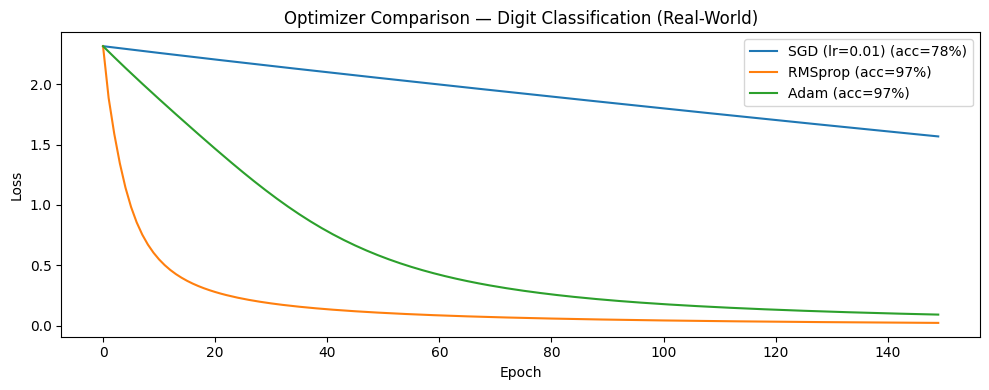

In [8]:
# WHAT: train the same small network three times, changing only the optimizer (SGD, RMSprop, Adam).
# WHY: with data, model and epochs held fixed, any difference in the loss curves comes from the update rule alone.
import torch, torch.nn as nn
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np, matplotlib.pyplot as plt

# Load the 8x8 digits dataset and standardize features so all optimizers start from comparable conditions.
digits = load_digits()
X = StandardScaler().fit_transform(digits.data.astype(np.float32))
y = digits.target
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
Xtr = torch.tensor(X_tr); Ytr = torch.tensor(y_tr, dtype=torch.long)
Xte = torch.tensor(X_te); Yte = torch.tensor(y_te, dtype=torch.long)

# A fresh model per optimizer - reusing weights would contaminate the comparison.
def make_model():
    torch.manual_seed(0)   # all three optimizers start from the SAME weights, every run
    return nn.Sequential(nn.Linear(64,128), nn.ReLU(), nn.Linear(128,10))

# The three contenders: plain SGD, RMSprop (adaptive step per weight), Adam (adaptive step + momentum).
optimizers = {
    'SGD (lr=0.01)':   lambda m: torch.optim.SGD(m.parameters(), lr=0.01),
    'RMSprop':         lambda m: torch.optim.RMSprop(m.parameters(), lr=1e-3),
    'Adam':            lambda m: torch.optim.Adam(m.parameters(), lr=1e-3),
}
results = {}
# Train 150 full-batch steps per optimizer and record the loss after each one.
for name, opt_fn in optimizers.items():
    model = make_model()
    opt   = opt_fn(model)
    loss_fn = nn.CrossEntropyLoss()
    curve = []
    for _ in range(150):
        model.train()
        loss = loss_fn(model(Xtr), Ytr)
        opt.zero_grad(); loss.backward(); opt.step()
        curve.append(loss.item())
    # Measure test accuracy with gradients off - training is done, we only evaluate.
    model.eval()
    with torch.no_grad():
        acc = (model(Xte).argmax(1)==Yte).float().mean().item()
    results[name] = (curve, acc)
    print(f"{name:20s} → final acc: {acc*100:.1f}%")

# One curve per optimizer: the faster-falling loss is the faster learner on this task.
plt.figure(figsize=(10,4))
for name,(curve,acc) in results.items():
    plt.plot(curve, label=f"{name} (acc={acc*100:.0f}%)")
plt.title("Optimizer Comparison — Digit Classification (Real-World)"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.tight_layout(); plt.show()

**Read the figure.** All three curves leave the same point (loss ≈ 2.33) because `make_model()` reseeds before each run: same network, same 1,437 training digits, same 150 full-batch steps, only the update rule differs. RMSprop (orange) is under 0.5 within about 20 steps; Adam (green) needs roughly 55–60; SGD at lr = 0.01 (blue) is still at 1.57 after all 150 and ends at **78.1%** test accuracy against 97.2% and 96.9%.

**Note what is different from the MNIST comparison above:** a different dataset (8×8 sklearn digits), full-batch instead of mini-batch, 150 steps instead of 5 epochs, and a third optimizer. The same ordering appears twice on two different setups — which is the only reason to trust it at all.

**What it does not prove:** that SGD cannot do this job. Its curve is nearly straight and still falling: the signature of a step size too small for this problem, not of a broken algorithm.

## ⚠️ Where this breaks

- **This experiment cannot tell you which optimizer generalises better.** We plotted *training* loss only. A lower training loss can mean better fitting or faster memorising, and nothing above distinguishes them. Add a validation curve before you draw a conclusion about quality.
- **The comparison is not perfectly fair, and it should say so.** SGD ran at `lr=0.01` and Adam at `lr=1e-3`. The starting weights were identical — genuinely good practice — but the step sizes were not tuned. A learning-rate sweep for SGD would close much of a gap this size.
- **Adam is not free.** It stores two extra numbers (the first and second moment) for every parameter, roughly tripling optimizer memory relative to plain SGD. On a large model that is exactly what decides whether training fits on your GPU at all.
- **Adam's edge shrinks or reverses with tuning and schedules.** Schmidt et al. found no dominant optimizer across 50,000+ runs. If a colleague reports "we switched to Adam and accuracy rose 4 points", the useful reply is a question about learning rates, not congratulations.
- **The assumption that must hold:** gradients carry usable signal. Where gradients are very sparse or very noisy, adaptive methods can amplify the noise instead of the signal.
- **Cheaper alternative:** for convex problems and small models, plain SGD with a decaying learning rate, or even a closed-form solver, is faster, simpler and fully predictable.


---

## 🧩 Mini-exercise

**Try it (choose one):** Train a third model with **RMSprop** (same architecture, 5 epochs) and add its loss curve to the plot. Compare SGD, Adam, and RMSprop. Or change the learning rate for SGD (e.g. 0.1 or 0.01) and see how the curve changes.

---

## ✅ Summary

**What you did:**
- Loaded MNIST subset and built two identical small models.
- Trained one with **SGD** and one with **Adam** for 5 epochs each.
- Plotted loss curves to compare; Adam often converges faster.

**In real life you'd also:** try different learning rates, use more epochs, and possibly try other optimizers (RMSprop, AdamW).

**The main idea:** The optimizer uses gradients from backprop to update weights; Adam adapts the step size per parameter and is often a good default.

**Next:** Unit 2 CNNs: e.g. `unit2-cnns/examples/01_cnn_architecture.ipynb`. Optionally, `07_image_processing_feature_extraction` (Unit 1) covers image basics before CNNs.


## 📚 References

1. Kingma, D. P. & Ba, J. (2015). *Adam: A Method for Stochastic Optimization*. ICLR. https://arxiv.org/abs/1412.6980
2. Ruder, S. (2016). *An overview of gradient descent optimization algorithms*. arXiv. https://arxiv.org/abs/1609.04747
3. Loshchilov, I. & Hutter, F. (2019). *Decoupled Weight Decay Regularization* (AdamW). ICLR. https://arxiv.org/abs/1711.05101
4. Schmidt, R. M., Schneider, F. & Hennig, P. (2021). *Descending through a Crowded Valley - Benchmarking Deep Learning Optimizers*. ICML. https://arxiv.org/abs/2007.01547

**Recent work (2024–2026)**

5. Liu, J. et al. (2025). *Muon is Scalable for LLM Training*. arXiv. https://arxiv.org/abs/2502.16982 — a 2025 optimizer that treats a layer's gradient as a matrix rather than a bag of scalars; the clearest recent challenge to the Adam/AdamW default this notebook compares.
6. Zhao, J. et al. (2024). *GaLore: Memory-Efficient LLM Training by Gradient Low-Rank Projection*. ICML 2024. https://arxiv.org/abs/2403.03507 — the memory side of the same question — the optimizer state, not the gradient computation, is what fills the GPU.
